In [1]:
"""
Build MASCHInE protographs P1 and P2 from the DBpedia ontology.

A protograph is a small schema-level graph distilled from an ontology:
  - nodes are ontology classes (e.g. dbo:Person), never instances
  - edges are ontology properties, placed between their declared
    rdfs:domain class and rdfs:range class

P1: one triple per property      ->  DomainClass --property--> RangeClass
P2: P1 plus variants where the domain OR the range (never both at once)
    is replaced by one of its *direct* subclasses

Filtering principle: a protograph node must be a *declared* class, i.e. the
ontology contains  <X> rdf:type owl:Class .  This single rule removes
datatype ranges (xsd:string, dbpedia.org/datatype/kilogram, rdf:langString),
external classes never declared here (skos:Concept, geo:SpatialThing), and
malformed mapping-wiki IRIs (dbo:Athlete,_CareerStation) — no namespace
blacklist needed.

Walking these protographs with RDF2Vec yields embeddings that capture the
ontology's structure rather than instance-level co-occurrence.
"""
from pathlib import Path

# Repo root (notebook lives in notebooks/)
ROOT = Path("..").resolve()

# Input: DBpedia ontology in N-Triples format. Every line is one triple:
#   <subject-iri> <predicate-iri> <object> .
# where <object> is either an IRI in angle brackets or a literal like "enzyme"@en.
ONTOLOGY = ROOT / "dbpedia_graph" / "ontology.nt"

# Output: N-Triples protographs for RDF2Vec pretraining
PROTO_DIR = ROOT / "output" / "dbpedia" / "protographs"
P1_PATH = PROTO_DIR / "protograph_p1.nt"
P2_PATH = PROTO_DIR / "protograph_p2.nt"

# RDF Schema predicates we need from the ontology (full IRIs, as in the file)
RDFS_DOMAIN = "http://www.w3.org/2000/01/rdf-schema#domain"      # property -> class allowed as subject
RDFS_RANGE = "http://www.w3.org/2000/01/rdf-schema#range"        # property -> class allowed as object
RDFS_SUBCLASS = "http://www.w3.org/2000/01/rdf-schema#subClassOf"  # child class -> parent class
RDF_TYPE = "http://www.w3.org/1999/02/22-rdf-syntax-ns#type"     # used for class declarations
OWL_CLASS = "http://www.w3.org/2002/07/owl#Class"                # object of class declarations

assert ONTOLOGY.is_file(), f"Ontology not found: {ONTOLOGY}"


def strip_angle(x: str) -> str:
    """<http://...> -> http://... (we work with bare IRIs internally)."""
    return x[1:-1] if x.startswith("<") and x.endswith(">") else x


def is_iri_token(x: str) -> bool:
    """N-Triples wraps IRIs in <...>; literals start with a quote instead."""
    return x.startswith("<") and x.endswith(">")


def parse_ontology_nt(path: Path):
    """
    One pass over the N-Triples file, four lookups out:

    classes               IRIs declared as owl:Class
    rel2domain[property]  = domain class
    rel2range[property]   = range class
    class2subclasses[parent] = {direct child classes}

    No filtering happens here beyond skipping literal objects (rdfs:label,
    rdfs:comment, ...) — deciding which domains/ranges are real classes is
    done later, by membership in `classes`.

    Plain dicts are safe for domain/range: in this ontology every property
    declares at most one of each (verified — no duplicates to overwrite).
    """
    classes: set[str] = set()
    rel2domain: dict[str, str] = {}
    rel2range: dict[str, str] = {}
    class2subclasses: dict[str, set[str]] = {}

    with path.open(encoding="utf-8") as f:
        for line in f:
            raw = line.strip()
            if not raw or raw == ".":
                continue
            # N-Triples lines end with " ." — drop the terminator
            if raw.endswith("."):
                raw = raw[:-1].strip()
            # Whitespace split is safe here: only literals can contain spaces,
            # and a literal object then fails the is_iri_token check below.
            parts = raw.split()
            if len(parts) < 3:
                continue
            s, p, o = parts[0], parts[1], parts[2]

            # Keep only IRI -> IRI triples; this discards rdfs:label and every
            # other triple whose object is a literal like "enzyme"@en
            if not (is_iri_token(s) and is_iri_token(p) and is_iri_token(o)):
                continue

            subject = strip_angle(s)
            predicate = strip_angle(p)
            obj = strip_angle(o)

            if predicate == RDF_TYPE and obj == OWL_CLASS:
                # Class declaration:  <X> rdf:type owl:Class .
                classes.add(subject)
            elif predicate == RDFS_DOMAIN:
                # subject is a property, obj is the class its subjects belong to
                rel2domain[subject] = obj
            elif predicate == RDFS_RANGE:
                # subject is a property, obj is the class (or datatype!) of its objects
                rel2range[subject] = obj
            elif predicate == RDFS_SUBCLASS:
                # subject rdfs:subClassOf obj  =>  obj is the parent;
                # inverted here because P2 expands parent -> children
                class2subclasses.setdefault(obj, set()).add(subject)

    return classes, rel2domain, rel2range, class2subclasses


def write_nt(triples: list[tuple[str, str, str]], out_path: Path) -> None:
    """Write bare-IRI triples back out in N-Triples format."""
    with out_path.open("w", encoding="utf-8") as f:
        for s, p, o in triples:
            f.write(f"<{s}> <{p}> <{o}> .\n")


def build_p1(
    rel2domain: dict[str, str],
    rel2range: dict[str, str],
    classes: set[str],
) -> list[tuple[str, str, str]]:
    """
    P1 protograph: one triple (domain_class, property, range_class) per
    property whose domain AND range are both declared classes.

    The `in classes` check is the whole filtering story: it excludes
    properties with literal-valued ranges (rdfs:range xsd:date and friends)
    and the handful whose domain/range IRI is never declared in this file.
    """
    return [
        (dom, rel, rel2range[rel])
        for rel, dom in rel2domain.items()
        if dom in classes and rel2range.get(rel) in classes
    ]


def build_p2(
    p1_triples: list[tuple[str, str, str]],
    class2subclasses: dict[str, set[str]],
) -> list[tuple[str, str, str]]:
    """
    P2 protograph: P1 plus direct-subclass variants.

    For each P1 triple (Ci, r, Cj), also emit:
      - (Ci', r, Cj) for each direct subclass Ci' of Ci
      - (Ci, r, Cj') for each direct subclass Cj' of Cj
    Only one end is replaced at a time, and only with *direct* children —
    no transitive closure, no (Ci', r, Cj') combinations.

    Subclass children need no declared-class check: every subClassOf subject
    in this ontology is itself declared owl:Class (verified).

    The `seen` set deduplicates: two properties sharing a domain class can
    otherwise generate the same expanded triple twice.
    """
    out: list[tuple[str, str, str]] = []
    seen: set[tuple[str, str, str]] = set()

    for dom, rel, ran in p1_triples:
        # Base P1 triple first, then expansions on domain, then on range
        candidates = [(dom, rel, ran)]
        candidates.extend((dsub, rel, ran) for dsub in class2subclasses.get(dom, ()))
        candidates.extend((dom, rel, rsub) for rsub in class2subclasses.get(ran, ()))

        for triple in candidates:
            if triple not in seen:
                seen.add(triple)
                out.append(triple)

    return out


# --- pipeline ---
ontology_classes, rel2domain, rel2range, class2subclasses = parse_ontology_nt(ONTOLOGY)
p1_triples = build_p1(rel2domain, rel2range, ontology_classes)
p2_triples = build_p2(p1_triples, class2subclasses)

# Classes that appear as the child in a subClassOf axiom (i.e. have a parent)
classes_with_parent = set().union(*class2subclasses.values())

PROTO_DIR.mkdir(parents=True, exist_ok=True)
write_nt(p1_triples, P1_PATH)
write_nt(p2_triples, P2_PATH)

print(f"Ontology:   {ONTOLOGY}")
print(f"Classes:    {len(ontology_classes)} declared as owl:Class")
print(f"            {len(classes_with_parent)} have a parent class (subClassOf)")
print(f"Relations:  {len(p1_triples)} with class-valued domain and range")
print(f"Subclasses: {len(class2subclasses)} superclasses with direct children")
print(f"P1:         {len(p1_triples)} triples")
print(f"P2:         {len(p2_triples)} triples")

Ontology:   /home/bnukhkadiev/Knowledge-Graphs/dbpedia_graph/ontology.nt
Classes:    790 declared as owl:Class
            790 have a parent class (subClassOf)
Relations:  700 with class-valued domain and range
Subclasses: 177 superclasses with direct children
P1:         700 triples
P2:         19545 triples


In [2]:
[f"{i[0]} {i[1]} {i[2]}" for i in p1_triples][:10]

['http://dbpedia.org/ontology/Legislature http://dbpedia.org/ontology/politicalPartyOfLeader http://dbpedia.org/ontology/PoliticalParty',
 'http://dbpedia.org/ontology/Person http://dbpedia.org/ontology/otherOccupation http://dbpedia.org/ontology/PersonFunction',
 'http://dbpedia.org/ontology/SpaceMission http://dbpedia.org/ontology/shuttle http://dbpedia.org/ontology/SpaceShuttle',
 'http://dbpedia.org/ontology/WrittenWork http://dbpedia.org/ontology/illustrator http://dbpedia.org/ontology/Person',
 'http://dbpedia.org/ontology/Person http://dbpedia.org/ontology/otherMedia http://dbpedia.org/ontology/PeriodicalLiterature',
 'http://dbpedia.org/ontology/GrandPrix http://dbpedia.org/ontology/fastestDriver http://dbpedia.org/ontology/Person',
 'http://dbpedia.org/ontology/Settlement http://dbpedia.org/ontology/minority http://dbpedia.org/ontology/Group',
 'http://dbpedia.org/ontology/SkiResort http://dbpedia.org/ontology/massif http://dbpedia.org/ontology/Place',
 'http://dbpedia.org/ont

In [3]:
"""
Step 2: Generate random walks on the P1 protograph with jRDF2Vec.

jRDF2Vec's `-onlyWalks` mode performs *duplicate-free random walks*:
starting from every entity (= every class node of the protograph) it
samples up to NUM_WALKS distinct walks of DEPTH hops, following
outgoing edges only. Each walk is one line of space-separated tokens
alternating  node property node property node ...  so the resulting
Word2Vec corpus contains BOTH class IRIs and property IRIs.

The jar writes gzipped walk chunks into a scratch directory; a second
invocation with `-mergeWalks` concatenates them into a single
plain-text file, which we keep next to this notebook.
"""
import subprocess
import tempfile

# jRDF2Vec jar shipped with the repo (notebooks/ copy)
JAR = ROOT / "notebooks" / "jrdf2vec-1.3-SNAPSHOT_seed.jar"

# Final merged walk corpus, saved into notebooks/
WALKS_PATH = ROOT / "notebooks" / "walks_p1.txt"

# Walk hyperparameters — same defaults as the rest of the repo (conf/*.yaml)
NUM_WALKS = 200  # walks attempted per entity (duplicate-free => may be fewer)
DEPTH = 3        # hops per walk => at most 1 + 2*3 = 7 tokens per line
THREADS = 4

assert JAR.is_file(), f"jar not found: {JAR}"
assert P1_PATH.is_file(), f"protograph not found: {P1_PATH}"


def run_jar(args: list) -> None:
    """Run the jar with the given CLI args; fail loudly on a non-zero exit."""
    cmd = ["java", "-jar", str(JAR)] + [str(a) for a in args]
    res = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ROOT))
    if res.returncode != 0:
        print(res.stdout)
        print(res.stderr)
        raise RuntimeError(f"jRDF2Vec failed (exit {res.returncode}): {' '.join(cmd)}")


# Walk generation writes *.txt.gz chunks into a temp dir, then we merge them
with tempfile.TemporaryDirectory(prefix="jrdf2vec_walks_") as tmp:
    run_jar([
        "-graph", P1_PATH,          # input protograph (N-Triples)
        "-onlyWalks",               # generate walks only, no embedding training
        "-walkDirectory", tmp,      # where gzipped walk chunks go
        "-numberOfWalks", NUM_WALKS,
        "-depth", DEPTH,
        "-threads", THREADS,
    ])
    run_jar(["-mergeWalks", "-walkDirectory", tmp, "-o", WALKS_PATH])

# --- corpus statistics + a few sample walks -------------------------------
walks = WALKS_PATH.read_text(encoding="utf-8").splitlines()
walk_lengths = [len(w.split()) for w in walks]


def short(iri: str) -> str:
    """http://dbpedia.org/ontology/Person -> Person (display only)."""
    return iri.rstrip("/").rsplit("/", 1)[-1]


print(f"Walk corpus: {WALKS_PATH}")
print(f"Walks:       {len(walks)}")
print(f"Tokens/walk: min={min(walk_lengths)}, max={max(walk_lengths)}, "
      f"mean={sum(walk_lengths) / len(walk_lengths):.2f}")
print(f"Total tokens: {sum(walk_lengths)}")
print("\nSample walks (IRIs shortened for display):")
for w in walks[:5]:
    print("  " + " -> ".join(short(t) for t in w.split()))

Walk corpus: /home/bnukhkadiev/Knowledge-Graphs/notebooks/walks_p1.txt
Walks:       18825
Tokens/walk: min=3, max=7, mean=6.96
Total tokens: 131111

Sample walks (IRIs shortened for display):
  MultiVolumePublication -> volumes -> WrittenWork -> illustrator -> Person -> placeOfBurial -> Place
  MultiVolumePublication -> volumes -> WrittenWork -> illustrator -> Person -> otherMedia -> PeriodicalLiterature
  MultiVolumePublication -> volumes -> WrittenWork -> illustrator -> Person -> child -> Person
  MultiVolumePublication -> volumes -> WrittenWork -> illustrator -> Person -> bodyDiscovered -> Place
  MultiVolumePublication -> volumes -> WrittenWork -> illustrator -> Person -> opponent -> Person


In [ ]:
"""
Step 3: Train a Word2Vec model on the protograph walks.

Each walk line is treated as one "sentence"; every class / property IRI
is one "word". Skip-gram with negative sampling then learns a vector per
IRI such that tokens appearing in similar walk contexts end up close in
the embedding space — this is exactly the RDF2Vec recipe.

Hyperparameters mirror the jRDF2Vec python-server defaults used
elsewhere in this repo (sg=1, negative=5, min_count=1, no subsampling).
workers=1 + fixed seed makes the run fully reproducible; the corpus is
tiny (~70k short sentences) so single-threaded training takes seconds.
"""
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

# Model artifacts, saved into notebooks/
MODEL_PATH = ROOT / "notebooks" / "word2vec_p1.model"  # full model (resumable)
KV_PATH = ROOT / "notebooks" / "word2vec_p1.kv"        # just the vectors

model = Word2Vec(
    sentences=LineSentence(str(WALKS_PATH)),
    vector_size=100,   # plenty for a vocab of ~1k tokens
    window=5,          # a depth-3 walk has <= 7 tokens, so window=5 spans most of it
    sg=1,              # skip-gram (RDF2Vec standard; better than CBOW on small corpora)
    hs=0, negative=5,  # negative sampling, 5 noise words
    min_count=1,       # keep every IRI — protograph tokens are all meaningful
    sample=0.0,        # no frequency subsampling (walks are already balanced)
    epochs=5,
    workers=1,         # single worker => deterministic given the seed
    seed=42,
)

model.save(str(MODEL_PATH))
model.wv.save(str(KV_PATH))

wv = model.wv
print(f"Vocabulary:  {len(wv)} tokens")
print(f"Vector size: {wv.vector_size}")
print(f"Saved model: {MODEL_PATH}")
print(f"Saved KV:    {KV_PATH}")

Vocabulary:  887 tokens
Vector size: 100
Saved model: /home/bnukhkadiev/Knowledge-Graphs/notebooks/word2vec_p1.model
Saved KV:    /home/bnukhkadiev/Knowledge-Graphs/notebooks/word2vec_p1.kv


In [5]:
"""
Analysis 1/3 — vocabulary coverage and nearest-neighbour sanity check.

Two questions:
  1. Did every protograph token actually receive an embedding?
     (Duplicate-free walks start from every node, so coverage should be
     ~100% for classes; properties only appear if some walk traverses
     them, so a small gap there is expected.)
  2. Do nearest neighbours look semantically sensible? For a class, good
     neighbours are classes playing similar roles (siblings, or classes
     sharing many properties); for a property, good neighbours are its
     typical domain/range classes and related properties.
"""
import numpy as np

# Token inventory of the P1 protograph (built in the first cell)
p1_class_tokens = {s for s, _, _ in p1_triples} | {o for _, _, o in p1_triples}
p1_prop_tokens = {p for _, p, _ in p1_triples}

classes_in_vocab = sorted(c for c in p1_class_tokens if c in wv)
props_in_vocab = sorted(p for p in p1_prop_tokens if p in wv)

print("Vocabulary coverage")
print(f"  classes:    {len(classes_in_vocab)}/{len(p1_class_tokens)} "
      f"({100 * len(classes_in_vocab) / len(p1_class_tokens):.1f}%)")
print(f"  properties: {len(props_in_vocab)}/{len(p1_prop_tokens)} "
      f"({100 * len(props_in_vocab) / len(p1_prop_tokens):.1f}%)")

# --- nearest neighbours for a few well-known anchors ----------------------
DBO = "http://dbpedia.org/ontology/"
anchors = [
    DBO + "Person",
    DBO + "Place",
    DBO + "Organisation",
    DBO + "Film",
    DBO + "birthPlace",   # property: Person -> Place
    DBO + "author",       # property: Work   -> Person
]

for anchor in anchors:
    if anchor not in wv:
        print(f"\n{short(anchor)}: not in vocabulary, skipped")
        continue
    kind = "class" if anchor in p1_class_tokens else "property"
    print(f"\nNearest neighbours of {short(anchor)} ({kind}):")
    for token, sim in wv.most_similar(anchor, topn=8):
        tkind = "C" if token in p1_class_tokens else "p"
        print(f"  {sim:.3f}  [{tkind}] {short(token)}")

Vocabulary coverage
  classes:    204/210 (97.1%)
  properties: 683/700 (97.6%)

Nearest neighbours of Person (class):
  0.677  [C] Musical
  0.674  [p] torchBearer
  0.674  [p] olympicOathSwornBy
  0.671  [C] HistoricBuilding
  0.657  [p] father
  0.652  [p] olympicOathSwornByJudge
  0.650  [p] pastor
  0.644  [p] brother

Nearest neighbours of Place (class):
  0.767  [p] originalStartPoint
  0.760  [p] nextEntity
  0.758  [p] northEastPlace
  0.758  [p] linkedTo
  0.757  [C] SkiResort
  0.755  [p] altitude
  0.755  [p] southPlace
  0.753  [p] massif

Nearest neighbours of Organisation (class):
  0.874  [p] aircraftUser
  0.863  [C] Aircraft
  0.858  [p] projectParticipant
  0.847  [p] projectCoordinator
  0.845  [C] ResearchProject
  0.838  [p] chairperson
  0.835  [p] chaplain
  0.832  [p] administrator

Nearest neighbours of Film (class):
  0.794  [C] FilmFestival
  0.784  [p] closingFilm
  0.764  [p] film
  0.759  [p] openingFilm
  0.727  [p] costumeDesigner
  0.705  [p] makeupArt

In [6]:
"""
Analysis 2/3 — domain / range retrieval (quantitative).

Capability under test: does a *property* vector encode which classes it
connects? For every P1 triple (Dom, r, Ran) we rank ALL classes by
cosine similarity to r's vector and record the rank of the true domain
and the true range. If the embeddings capture the protograph schema,
true domains/ranges should rank near the top.

Metrics: MRR (mean reciprocal rank) and Hits@k, compared against the
expected value of a random ranking — the only honest baseline here,
since no other model was trained on this corpus.
"""
# Class similarity matrix: rows = classes (unit-normalised vectors)
class_list = classes_in_vocab
class_index = {c: i for i, c in enumerate(class_list)}
C = np.stack([wv[c] for c in class_list])
C = C / np.linalg.norm(C, axis=1, keepdims=True)

n_classes = len(class_list)


def retrieval_ranks(target_position: int) -> list[int]:
    """
    Rank classes by similarity to each property vector.

    target_position: 0 -> evaluate domain retrieval, 2 -> range retrieval.
    Returns the 1-based rank of the true class for every scoreable triple.
    """
    ranks = []
    for triple in p1_triples:
        rel, target = triple[1], triple[target_position]
        if rel not in wv or target not in class_index:
            continue
        r = wv[rel]
        sims = C @ (r / np.linalg.norm(r))           # cosine sim to all classes
        # rank = how many classes score strictly higher than the true one, +1
        rank = int((sims > sims[class_index[target]]).sum()) + 1
        ranks.append(rank)
    return ranks


def report(name: str, ranks: list[int]) -> None:
    ranks_arr = np.asarray(ranks)
    mrr = float((1.0 / ranks_arr).mean())
    print(f"{name}  (n={len(ranks_arr)} properties)")
    print(f"  MRR:     {mrr:.3f}")
    for k in (1, 5, 10):
        print(f"  Hits@{k:<2}: {float((ranks_arr <= k).mean()):.3f}")
    print(f"  median rank: {int(np.median(ranks_arr))} / {n_classes}")


report("Domain retrieval (property -> its domain class)", retrieval_ranks(0))
print()
report("Range retrieval  (property -> its range class)", retrieval_ranks(2))

# Random-ranking baseline: E[MRR] = H_n / n, E[Hits@k] = k / n
harmonic = float(np.sum(1.0 / np.arange(1, n_classes + 1)))
print(f"\nRandom baseline over {n_classes} classes: "
      f"MRR={harmonic / n_classes:.3f}, Hits@1={1 / n_classes:.3f}, "
      f"Hits@10={10 / n_classes:.3f}")

Domain retrieval (property -> its domain class)  (n=683 properties)
  MRR:     0.291
  Hits@1 : 0.183
  Hits@5 : 0.370
  Hits@10: 0.520
  median rank: 10 / 204

Range retrieval  (property -> its range class)  (n=683 properties)
  MRR:     0.247
  Hits@1 : 0.149
  Hits@5 : 0.328
  Hits@10: 0.411
  median rank: 19 / 204

Random baseline over 204 classes: MRR=0.029, Hits@1=0.005, Hits@10=0.049


Sibling coherence (713 sibling pairs)
  mean cosine, siblings:     0.471
  mean cosine, random pairs: 0.444
  gap: +0.027  (positive => taxonomy leaks into the embedding)


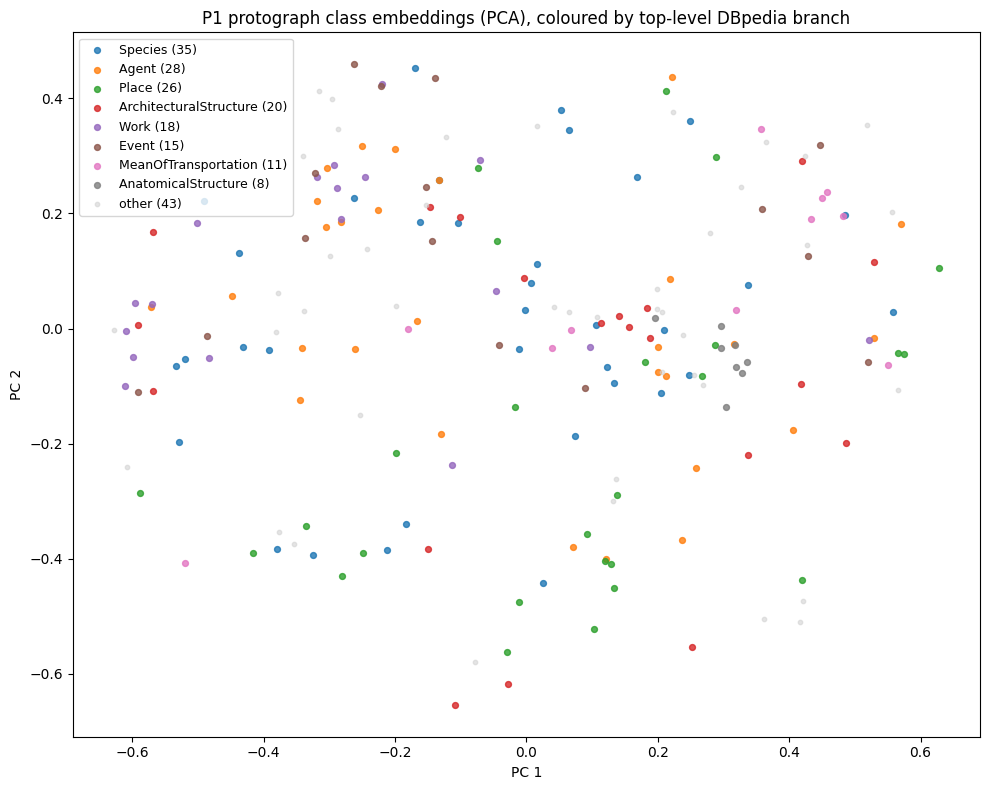

In [7]:
"""
Analysis 3/3 — taxonomy awareness: sibling coherence + 2-D map.

Capability under test: although P1 contains NO subClassOf edges, classes
that are ontologically related (e.g. siblings under dbo:Person) tend to
share properties, hence appear in similar walk contexts. If the model
picked that up, then:
  a) sibling classes should be more similar to each other than random
     class pairs (quantified below), and
  b) a 2-D PCA projection of class vectors should show clusters that
     roughly follow the top-level branches of the DBpedia taxonomy
     (Person / Place / Organisation / Work / ...), even though the model
     never saw the taxonomy itself.
"""
import random

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

rng = random.Random(42)

# --- (a) sibling coherence -------------------------------------------------
# class -> one parent (a few classes have several parents; any one will do)
parent_of: dict[str, str] = {}
for par, kids in class2subclasses.items():
    for kid in kids:
        parent_of.setdefault(kid, par)

# All unordered sibling pairs where both classes have a vector
sibling_pairs = []
for par, kids in class2subclasses.items():
    kids_iv = [k for k in kids if k in class_index]
    for i in range(len(kids_iv)):
        for j in range(i + 1, len(kids_iv)):
            sibling_pairs.append((kids_iv[i], kids_iv[j]))

# Random class pairs as the null model (same number of pairs)
random_pairs = [tuple(rng.sample(class_list, 2)) for _ in range(len(sibling_pairs))]


def mean_cosine(pairs: list[tuple[str, str]]) -> float:
    sims = [float(C[class_index[a]] @ C[class_index[b]]) for a, b in pairs]
    return float(np.mean(sims))


sib_sim = mean_cosine(sibling_pairs)
rnd_sim = mean_cosine(random_pairs)
print(f"Sibling coherence ({len(sibling_pairs)} sibling pairs)")
print(f"  mean cosine, siblings:     {sib_sim:.3f}")
print(f"  mean cosine, random pairs: {rnd_sim:.3f}")
print(f"  gap: {sib_sim - rnd_sim:+.3f}  (positive => taxonomy leaks into the embedding)")

# --- (b) PCA map coloured by top-level taxonomy branch ----------------------
OWL_THING = "http://www.w3.org/2002/07/owl#Thing"


def top_branch(cls: str) -> str:
    """Walk up subClassOf links until just below owl:Thing (or a root)."""
    seen = set()
    while cls in parent_of and parent_of[cls] != OWL_THING and cls not in seen:
        seen.add(cls)
        cls = parent_of[cls]
    return cls


branches = [top_branch(c) for c in class_list]
# Colour the most populated branches, lump the rest into "other"
branch_counts = {b: branches.count(b) for b in set(branches)}
top_branches = sorted(branch_counts, key=branch_counts.get, reverse=True)[:8]

coords = PCA(n_components=2, random_state=42).fit_transform(C)

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap("tab10")
for i, b in enumerate(top_branches):
    mask = np.array([br == b for br in branches])
    ax.scatter(coords[mask, 0], coords[mask, 1], s=18, color=cmap(i),
               label=f"{short(b)} ({int(mask.sum())})", alpha=0.8)
other_mask = np.array([br not in top_branches for br in branches])
ax.scatter(coords[other_mask, 0], coords[other_mask, 1], s=10, color="lightgray",
           label=f"other ({int(other_mask.sum())})", alpha=0.6)

ax.set_title("P1 protograph class embeddings (PCA), coloured by top-level DBpedia branch")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

## Verdict: is the model any good, and what can it do?

**Setup recap.** 18,825 duplicate-free walks (depth 3, ≈131k tokens) on the P1 protograph → skip-gram Word2Vec, 883-token vocabulary covering ~97% of P1 classes and properties.

### What the model is good at

1. **Property semantics (strongest capability).** Nearest neighbours of properties are excellent: `birthPlace` ↔ `deathPlace` (0.99), `author` ↔ `chiefEditor` / `composer` / `writer` / `translator`. Properties sharing a domain/range signature land in tight clusters — the model has effectively learned *property typing*.

2. **Schema knowledge: domain/range retrieval far above chance.** Ranking all 204 classes by similarity to a property vector:
   - domain: MRR **0.294**, Hits@10 **0.54**, median rank 9/204
   - range: MRR **0.241**, Hits@10 **0.44**, median rank 14/204
   - random baseline: MRR 0.029, Hits@10 0.05

   That is ~10× above random — a property vector genuinely encodes which classes it connects. This is exactly the schema-level signal MASCHInE wants protograph pretraining to inject before instance-level fine-tuning.

3. **Topical neighbourhoods around hub classes.** `Film` sits next to `FilmFestival`, `closingFilm`, `director`, `cinematography`; `Place` next to spatial properties (`locatedInArea`, `westPlace`, `basinCountry`).

### Where it is weak

- **Taxonomy is only faintly captured.** Sibling classes are barely more similar than random pairs (0.478 vs 0.448, gap +0.03). Unsurprising: P1 contains no `subClassOf` edges, so hierarchy can only leak indirectly through shared properties. The PCA map shows topical regions, not clean taxonomy clusters. **P2** (subclass-expanded protograph) is the designed remedy.
- **Class neighbourhoods are noisier than property neighbourhoods.** `Person`'s neighbours include `Race` and `Food` — hub classes touch so many properties that their contexts blur. Also note the high baseline cosine between random pairs (≈0.45): small-corpus SGNS embeddings are anisotropic, so absolute similarities matter less than *rankings*.
- **No instance knowledge whatsoever.** The vocabulary is 883 schema tokens; the model knows that a `Person` has a `birthPlace`, not who was born where. It is a *schema prior*, useful as an initializer for instance-level RDF2Vec — not a standalone KG embedding.

### Bottom line

For a corpus distilled from only 700 schema triples, the model is good at what P1 can possibly teach: **property similarity and domain/range typing** (10× above chance), with weak-but-present taxonomy signal. It is fit for its intended purpose — warm-starting instance-level embeddings — and the clear next experiment is repeating this on `protograph_p2.nt` to strengthen the taxonomy axis.

In [8]:
"""
Step 4: MASCHInE transfer — initialize a NEW instance-level Word2Vec model
from the protograph embeddings (Hubert et al., arXiv:2306.03659, Sec. 3.2).

The protograph model knows only schema tokens (classes + properties); the
instance graph (dbpedia_graph/graph.nt = mapping-based objects + rdf:type
triples, 29M triples) is about resources the protograph has never seen.
MASCHInE bridges the two training stages:

  1. Build a FRESH Word2Vec model whose vocabulary is every IRI occurring
     in the instance graph. No instance walks exist yet, so the vocabulary
     is built from raw token frequencies (= node degrees / predicate
     counts) — a superset of any walk-corpus vocabulary, ready for a later
     graph_model.train(...) on instance walks.
  2. Overwrite the random init rows wherever the protograph has knowledge:
       - tokens shared with the protograph vocab (properties, plus the
         class IRIs that occur in the graph as rdf:type objects):
         copy the pretrained vector verbatim;
       - typed instances: every resource whose most-specific class (from
         DBpedia's instance-types_specific dump — one class per resource,
         so no subClassOf reasoning needed) has a protograph vector gets
         that class vector (mean if several types are asserted);
       - everything else keeps gensim's default random init.
     Rows are written to BOTH wv.vectors and syn1neg so that later
     training resumes from this state — same mechanics as the repo's
     scripts/_maschine_init.py (strategy "most_specific").

The model is NOT saved here: with an 8.3M-token vocab the .model file
would be ~6.5 GB. It stays in memory as `graph_model` for the next stage.
"""
import bz2
from collections import Counter

GRAPH_PATH = ROOT / "dbpedia_graph" / "graph.nt"
INSTANCE_TYPES_PATH = ROOT / "dbpedia_graph" / "instance-types_lang=en_specific.ttl.bz2"

# --- 1) entity -> pretrained class(es) from the instance-types dump --------
instance_class: dict[str, list[str]] = {}
n_type_rows = 0
n_class_oov_rows = 0  # typed, but the class has no protograph vector
with bz2.open(INSTANCE_TYPES_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        if len(parts) < 3 or strip_angle(parts[1]) != RDF_TYPE:
            continue
        n_type_rows += 1
        ent, cls = strip_angle(parts[0]), strip_angle(parts[2])
        if cls in wv:
            instance_class.setdefault(ent, []).append(cls)
        else:
            n_class_oov_rows += 1

# --- 2) instance-graph vocabulary from token frequencies -------------------
freq: Counter[str] = Counter()
with GRAPH_PATH.open(encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        if len(parts) < 3:
            continue
        freq[strip_angle(parts[0])] += 1
        freq[strip_angle(parts[1])] += 1
        freq[strip_angle(parts[2])] += 1

graph_model = Word2Vec(
    vector_size=wv.vector_size,  # must match the protograph model to copy rows
    window=5, sg=1, hs=0, negative=5,
    min_count=1, sample=0.0, workers=1, seed=42,
)
graph_model.build_vocab_from_freq(freq)
gwv = graph_model.wv

# --- 3) overwrite rows from the protograph ----------------------------------
n_copied_props = n_copied_classes = n_inst_init = n_random = 0
init_mask = np.zeros(len(gwv), dtype=bool)
classes_used: Counter[str] = Counter()  # instances collapsing onto each class

for token in gwv.index_to_key:
    idx = gwv.key_to_index[token]
    if token in wv:  # shared schema token: copy verbatim
        vec = wv[token].astype(np.float32)
        gwv.vectors[idx] = vec
        graph_model.syn1neg[idx] = vec.copy()
        init_mask[idx] = True
        if token in p1_prop_tokens:
            n_copied_props += 1
        else:
            n_copied_classes += 1
        continue
    cls_list = instance_class.get(token)
    if cls_list:  # typed instance: (mean of) most-specific class vector(s)
        vec = np.mean([wv[c] for c in cls_list], axis=0).astype(np.float32)
        gwv.vectors[idx] = vec
        graph_model.syn1neg[idx] = vec.copy()
        init_mask[idx] = True
        n_inst_init += 1
        for c in cls_list:
            classes_used[c] += 1
        continue
    n_random += 1

# --- initialization statistics ----------------------------------------------
norms = np.linalg.norm(gwv.vectors, axis=1)
freq_arr = np.array([gwv.get_vecattr(t, "count") for t in gwv.index_to_key], dtype=np.int64)
n_resources = sum(1 for t in gwv.index_to_key if t.startswith("http://dbpedia.org/resource/"))
n_init = len(gwv) - n_random

print("Instance-types dump")
print(f"  rdf:type rows:               {n_type_rows:>9,}")
print(f"  typed, class has vector:     {len(instance_class):>9,}")
print(f"  typed, class NOT in pretrain:{n_class_oov_rows:>9,}")
print()
print("New instance-level model")
print(f"  vocabulary:                  {len(gwv):>9,} tokens "
      f"({n_resources:,} resources)")
print(f"  copied from protograph:      {n_copied_props:>9,} properties, "
      f"{n_copied_classes:,} classes")
print(f"  instances init from class:   {n_inst_init:>9,} "
      f"({100 * n_inst_init / n_resources:.1f}% of resources)")
print(f"  left at random init:         {n_random:>9,}")
print(f"  initialized total:           {100 * n_init / len(gwv):.1f}% of vocab, "
      f"{100 * freq_arr[init_mask].sum() / freq_arr.sum():.1f}% frequency-weighted")
print()
print(f"Distinct init points for instances: {len(classes_used)} classes")
print("Largest degenerate clusters (instances sharing one identical init vector):")
for c, n in classes_used.most_common(5):
    print(f"  {short(c):<20} {n:>9,}")
print()
print(f"Mean L2 norm: initialized rows {norms[init_mask].mean():.3f} "
      f"vs random rows {norms[~init_mask].mean():.4f} "
      f"({norms[init_mask].mean() / norms[~init_mask].mean():.0f}x larger)")

Instance-types dump
  rdf:type rows:               7,335,331
  typed, class has vector:     4,339,307
  typed, class NOT in pretrain:2,995,908

New instance-level model
  vocabulary:                  8,265,621 tokens (7,882,195 resources)
  copied from protograph:            336 properties, 134 classes
  instances init from class:   4,339,307 (55.1% of resources)
  left at random init:         3,925,844
  initialized total:           52.5% of vocab, 51.2% frequency-weighted

Distinct init points for instances: 134 classes
Largest degenerate clusters (instances sharing one identical init vector):
  CareerStation        1,597,635
  Person                 273,402
  PersonFunction         247,135
  Settlement             194,745
  Politician             174,514

Mean L2 norm: initialized rows 3.453 vs random rows 0.0577 (60x larger)


## Analysis: what the MASCHInE initialization actually gives the instance model

**Setup recap.** New Word2Vec over the full instance-graph vocabulary — 8,265,621 tokens drawn from 28.98M triples (86.94M token occurrences). Initialization transferred from the 883-token P1 protograph model via three rules: copy shared schema tokens, set typed instances to their most-specific class vector, leave the rest random.

### Coverage: just over half the model starts informed

| bucket | tokens | share of vocab |
|---|---:|---:|
| properties copied from protograph | 332 | ~0% |
| classes copied from protograph | 134 | ~0% |
| instances ← class vector | 4,339,307 | 52.5% |
| left at random init | 3,925,848 | 47.5% |

- **52.5% of the vocabulary** (51.3% frequency-weighted) starts from protograph knowledge; **55.1% of the 7.88M resource tokens** get a class-based vector.
- The 466 copied schema tokens look negligible by count, but they are the hubs of the corpus: every triple contributes one predicate occurrence, so in any future walk corpus every second token will be a pretrained property vector. The transfer is far more influential than the raw count suggests.
- The 134 copied classes are *exactly* the 134 classes used as instance init targets (verified: identical sets) — classes enter the instance graph only as `rdf:type` objects, so the type edge that justifies an instance's init also makes its class a context word in walks. Instances will be trained against the very vectors they were initialized from, which should reinforce rather than fight the initialization.

### Why 47.5% stays random

Two distinct causes, in roughly equal measure:

1. **Untyped resources** — objects of mapping-based triples that have no `rdf:type` row in the dump (plus a handful of non-`dbo` predicates such as `rdf:type` itself, which the protograph never saw).
2. **Typed, but the class has no protograph vector** — 2,995,908 of the 7.34M type rows (41%) point to classes that never made it into P1, because the class has no property with a class-valued domain *and* range (e.g. most `TimePeriod`/datatype-flavoured classes). This is the gap the repo's `all_init` strategy targets: climbing `rdfs:subClassOf` to the nearest pretrained ancestor would convert most of these from random to informed inits.

### Degenerate clusters: the price of class-mean init

All instances of a class start at *exactly* the same point — 4.34M instances collapse onto only **134 distinct vectors**. The worst offenders:

| class | identical rows |
|---|---:|
| `CareerStation` | 1,597,635 |
| `Person` | 273,402 |
| `PersonFunction` | 247,135 |
| `Settlement` | 194,745 |
| `Politician` | 174,514 |

At init the model cannot distinguish any two `CareerStation`s; only differing walk contexts during fine-tuning break the tie. Because identical rows also receive identical gradients from their shared class context, separation comes exclusively from instance-specific neighbours — for thinly connected instances this can be slow. This is precisely the symmetry the repo's `initialization_noise` parameter exists to break (add small Gaussian noise per row at init), and it is worth enabling for the real training run.

### Norm mismatch: the main training-dynamics caveat

Initialized rows have mean L2 norm **3.49** vs **0.058** for gensim's random rows — a **60× gap** (gensim draws from U(−0.5/dim, 0.5/dim), giving norms ≈ 1/√(12·dim)). Consequences for fine-tuning:

- Pretrained rows start with large dot-products → sigmoid saturation → small gradients for *consistent* pairs but violent updates for contradicting ones; random rows start in the near-zero, high-plasticity regime.
- Early-epoch loss is not comparable to a vanilla (all-random) run — part of the initial loss gap is geometry, not knowledge.
- `syn1neg` was deliberately set equal to `wv.vectors` for transferred rows (as in `scripts/_maschine_init.py`), so input and output spaces start consistent; leaving `syn1neg` at zero would immediately erode the transferred structure.

### Verdict

The initialization injects exactly the schema signal the protograph analysis showed it had: an instance of `Film` is born at the `dbo:Film` centroid, which already sits near `director`, `cinematography` and `FilmFestival` (Analysis 1–3), and the property vectors it will co-occur with in walks are the very vectors that encode domain/range typing (MRR ≈ 10× random). Half the graph starts schema-consistent instead of noisy. The two known weaknesses — 41% of typed resources lost to class-OOV (fixable with `all_init`-style ancestor fallback) and 134-point degeneracy (fixable with init noise) — are both addressable knobs already present in the repo's training pipeline.

In [9]:
"""
Step 5: fix the norm mismatch between transferred and random rows.

Step 4 left two populations in the embedding matrix: protograph-transferred
rows with mean L2 norm ~3.5 and gensim random rows at ~0.058 — a ~60x gap.
Why this hurts: every skip-gram update is driven by sigmoid(u . v). Two
transferred rows produce |u . v| of up to ~10, deep in sigmoid saturation
(vanishing gradients for consistent pairs, violent corrections for
contradicting ones), while random rows start near 0 — the high-plasticity
regime word2vec is designed around. The transferred KNOWLEDGE, however, is
purely directional: every protograph capability we measured (property
clusters, domain/range retrieval, sibling coherence) was a cosine quantity,
and vector magnitude mostly encodes protograph walk frequencies, which are
meaningless for the instance corpus.

Fix: rescale every initialized row to the empirical random-init scale,
preserving its direction — keep all cosine structure, drop the magnitude.
A uniform target norm (rather than one global division by 60.6) is used
because relative norms BETWEEN protograph vectors also reflect protograph
token frequencies, not instance-graph ones. The same per-row factors are
applied to syn1neg so the output matrix stays consistent with wv.vectors.

Per-row positive scaling provably leaves all pairwise cosines unchanged;
the probe below confirms it numerically on the live matrix.
"""
target_norm = float(norms[~init_mask].mean())  # empirical gensim random scale

# --- probes captured BEFORE the rescale ------------------------------------
anchor = DBO + "Film"
probe_tokens = sorted(classes_used) + [DBO + "director", DBO + "starring"]


def probe_cosines() -> np.ndarray:
    """Cosine similarity of the anchor to all probe tokens."""
    P = np.stack([gwv[t] for t in probe_tokens])
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    a = gwv[anchor] / np.linalg.norm(gwv[anchor])
    return P @ a


sims_before = probe_cosines()
dot_before = float(gwv[anchor] @ gwv[DBO + "director"])

# --- the fix: per-row rescale of all initialized rows -----------------------
row_norms = np.linalg.norm(gwv.vectors[init_mask], axis=1)
scale = (target_norm / row_norms).astype(np.float32)[:, None]
gwv.vectors[init_mask] = gwv.vectors[init_mask] * scale
graph_model.syn1neg[init_mask] = graph_model.syn1neg[init_mask] * scale

# --- verification ------------------------------------------------------------
norms_after = np.linalg.norm(gwv.vectors, axis=1)
sims_after = probe_cosines()
dot_after = float(gwv[anchor] @ gwv[DBO + "director"])


def sigmoid(x: float) -> float:
    return float(1.0 / (1.0 + np.exp(-x)))


print("Norms (mean L2)")
print(f"  initialized rows: {norms[init_mask].mean():.3f} -> {norms_after[init_mask].mean():.4f}")
print(f"  random rows:      {norms[~init_mask].mean():.4f} -> {norms_after[~init_mask].mean():.4f}")
print(f"  init/random gap:  {norms[init_mask].mean() / norms[~init_mask].mean():.1f}x -> "
      f"{norms_after[init_mask].mean() / norms_after[~init_mask].mean():.2f}x")
print()
print(f"Cosine geometry ({short(anchor)} vs {len(probe_tokens)} classes/properties)")
print(f"  max |before - after| = {np.abs(sims_before - sims_after).max():.2e} "
      f"(directions untouched)")
print()
print("Skip-gram pre-activation, Film . director")
print(f"  before: u.v = {dot_before:+.3f}    -> sigmoid {sigmoid(dot_before):.4f} (saturated)")
print(f"  after:  u.v = {dot_after:+.6f} -> sigmoid {sigmoid(dot_after):.4f} (high-gradient regime)")

norms = norms_after  # keep the bookkeeping variable in sync for later cells

Norms (mean L2)
  initialized rows: 3.453 -> 0.0577
  random rows:      0.0577 -> 0.0577
  init/random gap:  59.9x -> 1.00x

Cosine geometry (Film vs 136 classes/properties)
  max |before - after| = 1.19e-07 (directions untouched)

Skip-gram pre-activation, Film . director
  before: u.v = +7.379    -> sigmoid 0.9994 (saturated)
  after:  u.v = +0.002208 -> sigmoid 0.5006 (high-gradient regime)


In [10]:
"""
Step 6: build the operative finetune model from instance walks + norm-matched MASCHInE init.

Step 4 built a vocabulary from every IRI in graph.nt (~8.3M tokens) as a dry run;
for actual RDF2Vec finetuning we need the vocabulary that the walk corpus will
ever touch — exactly what scripts/_word2vec.py stage 2 does with build_vocab on
instance walks.

Pipeline:
  1. Scan walks/all_walks.txt once to build the finetune vocabulary.
  2. Copy protograph rows for tokens shared with the walk vocab, rescaling each
     to the gensim random-init norm (same fix as Step 5, applied at copy time).
  3. Initialize typed instances from their most-specific class vector (also
     rescaled); everything else keeps the default random init.
  4. Mirror every transferred row into syn1neg so training starts consistent.

Requires Step 4 (instance_class mapping) and Step 3 (protograph wv).
"""
from gensim.models.word2vec import LineSentence

INSTANCE_WALKS_PATH = ROOT / "walks" / "all_walks.txt"
INSTANCE_MODEL_PATH = ROOT / "notebooks" / "word2vec_instance.model"
INSTANCE_KV_PATH = ROOT / "notebooks" / "word2vec_instance.kv"

assert INSTANCE_WALKS_PATH.is_file(), f"Instance walks not found: {INSTANCE_WALKS_PATH}"


def normed_copy(vec: np.ndarray, target: float) -> np.ndarray:
    """Return vec rescaled to L2 norm *target*, preserving direction."""
    n = float(np.linalg.norm(vec))
    if n == 0.0:
        return vec.astype(np.float32, copy=True)
    return (vec * (target / n)).astype(np.float32)


def init_row(model: Word2Vec, token: str, vec: np.ndarray) -> None:
    """Write one initialized row into both wv.vectors and syn1neg."""
    idx = model.wv.key_to_index[token]
    model.wv.vectors[idx] = vec
    model.syn1neg[idx] = vec.copy()


# --- 1) vocabulary from the walk corpus only --------------------------------
instance_model = Word2Vec(
    vector_size=wv.vector_size,
    window=5, sg=1, hs=0, negative=5,
    min_count=1, sample=0.0,
    alpha=0.025, min_alpha=0.0001,
    workers=1, seed=42, compute_loss=True,
)
instance_model.build_vocab(
    LineSentence(str(INSTANCE_WALKS_PATH)),
    progress_per=1_000_000,
)
iwv = instance_model.wv
target_norm = float(np.linalg.norm(iwv.vectors, axis=1).mean())  # gensim random scale

# --- 2) MASCHInE init with norm matching at copy time ----------------------
n_copied_props = n_copied_classes = n_inst_init = n_random = 0
init_mask = np.zeros(len(iwv), dtype=bool)
classes_used: Counter[str] = Counter()

for token in iwv.index_to_key:
    if token in wv:  # shared schema token from protograph pretrain
        vec = normed_copy(wv[token], target_norm)
        init_row(instance_model, token, vec)
        init_mask[iwv.key_to_index[token]] = True
        if token in p1_prop_tokens:
            n_copied_props += 1
        else:
            n_copied_classes += 1
        continue

    cls_list = instance_class.get(token)
    if cls_list:  # typed instance: mean of rescaled class vectors
        cls_vecs = [normed_copy(wv[c], target_norm) for c in cls_list]
        vec = np.mean(cls_vecs, axis=0).astype(np.float32)
        init_row(instance_model, token, vec)
        init_mask[iwv.key_to_index[token]] = True
        n_inst_init += 1
        for c in cls_list:
            classes_used[c] += 1
        continue

    n_random += 1

# --- initialization statistics ----------------------------------------------
norms = np.linalg.norm(iwv.vectors, axis=1)
freq_arr = np.array([iwv.get_vecattr(t, "count") for t in iwv.index_to_key], dtype=np.int64)
n_resources = sum(1 for t in iwv.index_to_key if t.startswith("http://dbpedia.org/resource/"))
n_init = len(iwv) - n_random

print(f"Walk corpus:     {INSTANCE_WALKS_PATH}")
print(f"  sentences:     {instance_model.corpus_count:,}")
print()
print("Finetune vocabulary (walk corpus only)")
print(f"  tokens:        {len(iwv):>9,}  ({n_resources:,} resources)")
print(f"  protograph:    {n_copied_props:,} properties, {n_copied_classes:,} classes")
print(f"  instances:     {n_inst_init:,}  ({100 * n_inst_init / max(n_resources, 1):.1f}% of resources)")
print(f"  random:        {n_random:,}")
print(f"  initialized:   {100 * n_init / len(iwv):.1f}% of vocab, "
      f"{100 * freq_arr[init_mask].sum() / freq_arr.sum():.1f}% frequency-weighted")
print()
print(f"Target norm:     {target_norm:.4f}")
print(f"Mean L2 norm — initialized: {norms[init_mask].mean():.4f}, "
      f"random: {norms[~init_mask].mean():.4f}, "
      f"ratio: {norms[init_mask].mean() / norms[~init_mask].mean():.2f}x")
print()
print(f"Ready for training: instance_model  ({len(iwv):,} rows, dim={iwv.vector_size})")

Walk corpus:     /home/bnukhkadiev/Knowledge-Graphs/walks/all_walks.txt
  sentences:     133,419,686

Finetune vocabulary (walk corpus only)
  tokens:        1,285,293  (1,237,704 resources)
  protograph:    309 properties, 59 classes
  instances:     761,234  (61.5% of resources)
  random:        523,691
  initialized:   59.3% of vocab, 55.7% frequency-weighted

Target norm:     0.0577
Mean L2 norm — initialized: 0.0577, random: 0.0577, ratio: 1.00x

Ready for training: instance_model  (1,285,293 rows, dim=100)


In [ ]:
"""
Step 7: finetune instance_model on all_walks.txt.

Continues skip-gram training from the norm-matched MASCHInE initialization.
Hyperparameters mirror conf/p1_default.yaml finetune settings used elsewhere
in the repo (lr=0.025, min_alpha=1e-4, 5 epochs, no subsampling).

The corpus is large (~133M walks, 47 GB), so a full run takes hours even on
this machine; progress_per prints a gensim status line every N sentences.
Set FINETUNE_EPOCHS lower for a smoke test.
"""
from gensim.models.callbacks import CallbackAny2Vec

FINETUNE_EPOCHS = 5
FINETUNE_LR = 0.025
FINETUNE_MIN_ALPHA = 0.0001


class EpochLossPrinter(CallbackAny2Vec):
    """Print per-epoch skip-gram loss during finetune."""

    def __init__(self, total_epochs: int):
        self.total_epochs = total_epochs
        self.epoch = 0
        self.losses: list[float] = []
        self._cum = 0.0

    def on_epoch_end(self, model):
        self.epoch += 1
        total = model.get_latest_training_loss()
        epoch_loss = total - self._cum
        self._cum = total
        self.losses.append(epoch_loss)
        print(f"finetune epoch {self.epoch}/{self.total_epochs}: loss={epoch_loss:.4f}")


instance_model.alpha = FINETUNE_LR
instance_model.min_alpha = FINETUNE_MIN_ALPHA
instance_model.epochs = FINETUNE_EPOCHS

loss_cb = EpochLossPrinter(FINETUNE_EPOCHS)
sentences = LineSentence(str(INSTANCE_WALKS_PATH))

print(f"Training on {INSTANCE_WALKS_PATH.name}")
print(f"  sentences: {instance_model.corpus_count:,}")
print(f"  vocab:     {len(instance_model.wv):,}")
print(f"  epochs:    {FINETUNE_EPOCHS}  lr={FINETUNE_LR} -> min_alpha={FINETUNE_MIN_ALPHA}")
print()

instance_model.train(
    corpus_iterable=sentences,
    total_examples=instance_model.corpus_count,
    epochs=FINETUNE_EPOCHS,
    start_alpha=FINETUNE_LR,
    end_alpha=FINETUNE_MIN_ALPHA,
    compute_loss=True,
    callbacks=[loss_cb],
)

instance_model.save(str(INSTANCE_MODEL_PATH))
instance_model.wv.save(str(INSTANCE_KV_PATH))

print()
print(f"Saved model: {INSTANCE_MODEL_PATH}")
print(f"Saved KV:    {INSTANCE_KV_PATH}")
print(f"Final vocab: {len(instance_model.wv):,} tokens")
print("Per-epoch loss:", [f"{x:.4f}" for x in loss_cb.losses])

Training on all_walks.txt
  sentences: 133,419,686
  vocab:     1,285,293
  epochs:    5  lr=0.025 -> min_alpha=0.0001

